# Decision Tree

In [20]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree, export_text
from sklearn.metrics import classification_report, ConfusionMatrixDisplay

In [65]:
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)

## 1. Train, Evaluate & Visualise

In [ ]:
# ── Data ──────────────────────────────────────────────────────────────
data = load_breast_cancer()
X, y = data.data, data.target
feature_names, class_names = data.feature_names, data.target_names

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)

# ── Model ─────────────────────────────────────────────────────────────
clf = DecisionTreeClassifier(
    criterion       = "gini",
    max_depth       = 4,
    min_samples_leaf = 5,
    random_state    = 42
)
clf.fit(X_train, y_train)

# ── Scores ────────────────────────────────────────────────────────────
print(f"Train : {clf.score(X_train, y_train):.3f}")
print(f"Test  : {clf.score(X_test,  y_test):.3f}")
print(classification_report(y_test, clf.predict(X_test), target_names=class_names))

Train : 0.977
Test  : 0.930
              precision    recall  f1-score   support

   malignant       0.91      0.91      0.91        53
      benign       0.94      0.94      0.94        90

    accuracy                           0.93       143
   macro avg       0.93      0.93      0.93       143
weighted avg       0.93      0.93      0.93       143



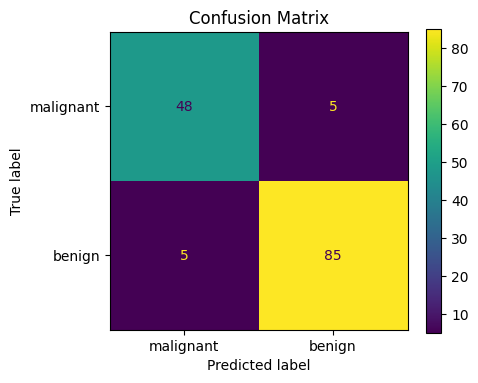

In [17]:
# ── Confusion Matrix ──────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay.from_estimator(
    clf, X_test, y_test, display_labels=class_names, ax=ax
)
plt.title("Confusion Matrix"); plt.tight_layout(); plt.show()

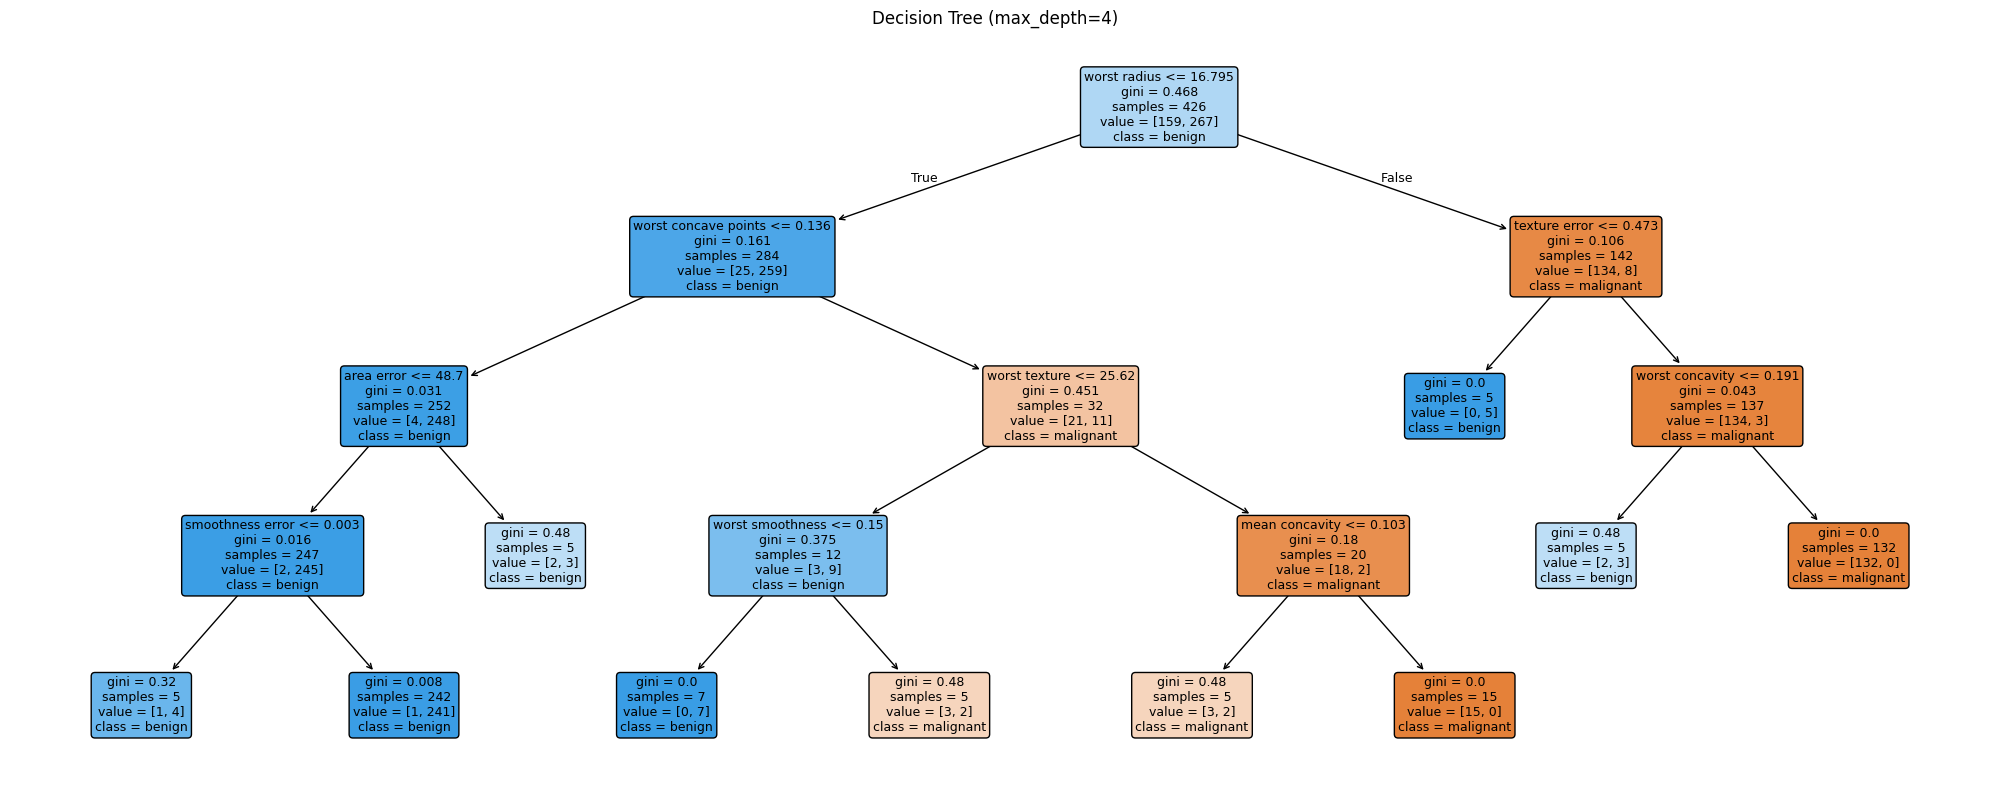

In [18]:
# ── Tree Diagram ──────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(20, 8))
plot_tree(clf, feature_names=feature_names, class_names=class_names,
          filled=True, rounded=True, fontsize=9, ax=ax)
plt.title("Decision Tree (max_depth=4)"); plt.tight_layout(); plt.show()

In [19]:
# ── Text Rules ────────────────────────────────────────────────────────
print(export_text(clf, feature_names=list(feature_names)))

|--- worst radius <= 16.80
|   |--- worst concave points <= 0.14
|   |   |--- area error <= 48.70
|   |   |   |--- smoothness error <= 0.00
|   |   |   |   |--- class: 1
|   |   |   |--- smoothness error >  0.00
|   |   |   |   |--- class: 1
|   |   |--- area error >  48.70
|   |   |   |--- class: 1
|   |--- worst concave points >  0.14
|   |   |--- worst texture <= 25.62
|   |   |   |--- worst smoothness <= 0.15
|   |   |   |   |--- class: 1
|   |   |   |--- worst smoothness >  0.15
|   |   |   |   |--- class: 0
|   |   |--- worst texture >  25.62
|   |   |   |--- mean concavity <= 0.10
|   |   |   |   |--- class: 0
|   |   |   |--- mean concavity >  0.10
|   |   |   |   |--- class: 0
|--- worst radius >  16.80
|   |--- texture error <= 0.47
|   |   |--- class: 1
|   |--- texture error >  0.47
|   |   |--- worst concavity <= 0.19
|   |   |   |--- class: 1
|   |   |--- worst concavity >  0.19
|   |   |   |--- class: 0



## 2. Bias–Variance Plot: Sweeping `max_depth`

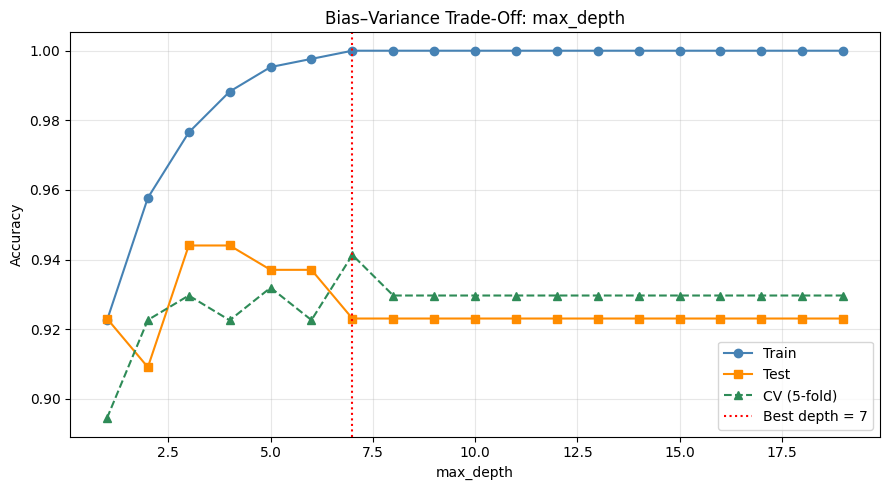

In [21]:
from sklearn.model_selection import cross_val_score

depths = range(1, 20)
train_acc, test_acc, cv_acc = [], [], []

for d in depths:
    dt = DecisionTreeClassifier(max_depth=d, random_state=42)
    dt.fit(X_train, y_train)
    train_acc.append(dt.score(X_train, y_train))
    test_acc.append(dt.score(X_test,  y_test))
    cv_acc.append(cross_val_score(dt, X_train, y_train, cv=5).mean())

best_d = depths[np.argmax(cv_acc)]

plt.figure(figsize=(9, 5))
plt.plot(depths, train_acc, "o-",  label="Train",      color="steelblue")
plt.plot(depths, test_acc,  "s-",  label="Test",       color="darkorange")
plt.plot(depths, cv_acc,    "^--", label="CV (5-fold)", color="seagreen")
plt.axvline(best_d, color="red", linestyle=":",
            label=f"Best depth = {best_d}")
plt.xlabel("max_depth"); plt.ylabel("Accuracy")
plt.title("Bias–Variance Trade-Off: max_depth")
plt.legend(); plt.grid(alpha=0.3); plt.tight_layout(); plt.show()

## 3. Post-Pruning: `ccp_alpha` Path

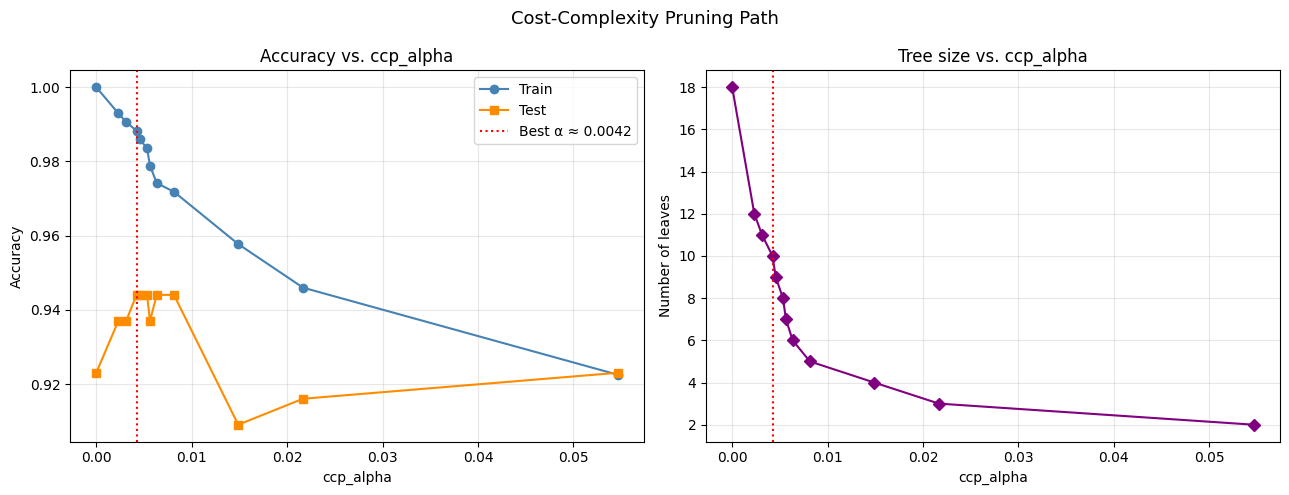

Best ccp_alpha : 0.0042
Test accuracy  : 0.944


,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [22]:
# ── Step 1: Pruning path ──────────────────────────────────────────────
path       = DecisionTreeClassifier(random_state=42)\
                 .cost_complexity_pruning_path(X_train, y_train)
ccp_alphas = path.ccp_alphas[:-1]     # drop trivial root-only tree

# ── Step 2: Train one tree per alpha ─────────────────────────────────
train_acc, test_acc, n_leaves = [], [], []
for alpha in ccp_alphas:
    dt = DecisionTreeClassifier(ccp_alpha=alpha, random_state=42)
    dt.fit(X_train, y_train)
    train_acc.append(dt.score(X_train, y_train))
    test_acc.append(dt.score(X_test,  y_test))
    n_leaves.append(dt.get_n_leaves())

best_alpha = ccp_alphas[np.argmax(test_acc)]

# ── Step 3: Plot ──────────────────────────────────────────────────────
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

ax1.plot(ccp_alphas, train_acc, "o-", label="Train", color="steelblue")
ax1.plot(ccp_alphas, test_acc,  "s-", label="Test",  color="darkorange")
ax1.axvline(best_alpha, color="red", linestyle=":",
            label=f"Best α ≈ {best_alpha:.4f}")
ax1.set_xlabel("ccp_alpha"); ax1.set_ylabel("Accuracy")
ax1.set_title("Accuracy vs. ccp_alpha")
ax1.legend(); ax1.grid(alpha=0.3)

ax2.plot(ccp_alphas, n_leaves, "D-", color="purple")
ax2.axvline(best_alpha, color="red", linestyle=":")
ax2.set_xlabel("ccp_alpha"); ax2.set_ylabel("Number of leaves")
ax2.set_title("Tree size vs. ccp_alpha")
ax2.grid(alpha=0.3)

plt.suptitle("Cost-Complexity Pruning Path", fontsize=13)
plt.tight_layout(); plt.show()

print(f"Best ccp_alpha : {best_alpha:.4f}")
print(f"Test accuracy  : {max(test_acc):.3f}")

# ── Step 4: Final pruned model ────────────────────────────────────────
best_tree = DecisionTreeClassifier(ccp_alpha=best_alpha, random_state=42)
best_tree.fit(X_train, y_train)

## 4. GridSearchCV Hyperparameter Tuning

In [23]:
from sklearn.model_selection import GridSearchCV

params = {
    'max_depth':             [3, 5, 7, 10, None],
    'min_samples_split':     [2, 10, 20, 0.05],
    'min_samples_leaf':      [1, 5, 10],
    'min_impurity_decrease': [0.0, 0.01, 0.02],
    'max_leaf_nodes':        [None, 20, 50],
    'ccp_alpha':             [0.0, 0.005, 0.01],
}

grid = GridSearchCV(
    DecisionTreeClassifier(random_state=42),
    param_grid = params,
    cv         = 5,
    scoring    = 'accuracy',
    n_jobs     = -1,
    verbose    = 1
)
grid.fit(X_train, y_train)

print("Best params :", grid.best_params_)
print(f"CV accuracy : {grid.best_score_:.3f}")
print(f"Test accuracy: {grid.score(X_test, y_test):.3f}")

Fitting 5 folds for each of 1620 candidates, totalling 8100 fits
Best params : {'ccp_alpha': 0.0, 'max_depth': 7, 'max_leaf_nodes': None, 'min_impurity_decrease': 0.0, 'min_samples_leaf': 1, 'min_samples_split': 2}
CV accuracy : 0.941
Test accuracy: 0.923


## 5. Feature Importance Plot

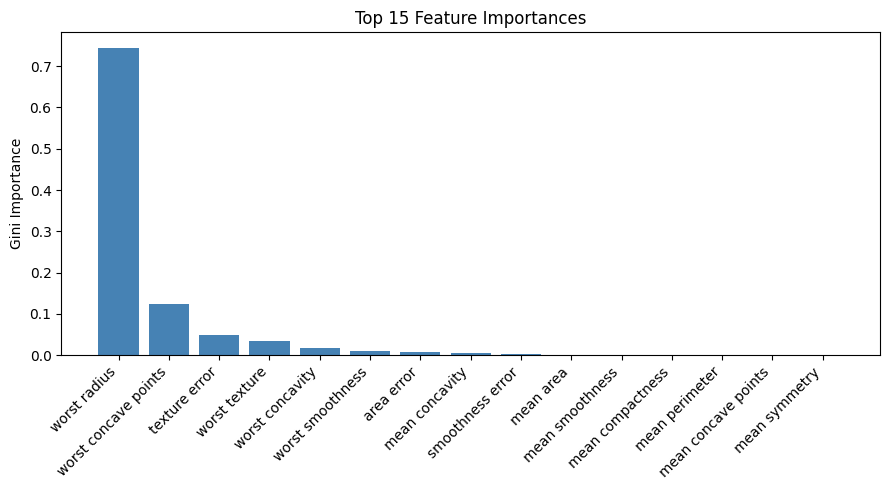

In [24]:
importances = clf.feature_importances_
top_idx = np.argsort(importances)[::-1][:15]

plt.figure(figsize=(9, 5))
plt.bar(range(len(top_idx)), importances[top_idx], color="steelblue")
plt.xticks(range(len(top_idx)),
           [feature_names[i] for i in top_idx], rotation=45, ha="right")
plt.ylabel("Gini Importance")
plt.title("Top 15 Feature Importances")
plt.tight_layout(); plt.show()

## 6. C4.5 with the "Heart Disease" Dataset
Since ID3 only handles categorical data, we must "bin" our numbers. For example, instead of using 145 mmHg for blood pressure, we categorize it as "High" or "Normal."

We'll use Chefboost, as it is designed to handle these classic symbolic logic trees.

In [66]:
import pandas as pd
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from chefboost import Chefboost

# Load data
data = load_breast_cancer()
X = pd.DataFrame(data.data, columns=data.feature_names)
df = X.copy()
df["target"] = data.target  # target column in the dataframe
df["target"] = df["target"].astype(int)

# Convert all columns to Python native types
for col in df.columns:
    if df[col].dtype == "float64" or df[col].dtype == "float32":
        df[col] = df[col].astype(float)
    elif df[col].dtype == "int64" or df[col].dtype == "int32":
        df[col] = df[col].astype(int)
    else:
        df[col] = df[col].astype(str)

# Ensure no missing values
assert not df.isnull().any().any(), "Data contains missing values!"

train_df, test_df = train_test_split(
    df, test_size=0.25, random_state=42, stratify=df["target"]
)

config = {
    "algorithm": "C4.5",
    "enableParallelism": False,
    "num_cores": 1,
    'verbose': False,
    "target_label": "target"
}

model = Chefboost.fit(train_df, config, target_label="target")

# Predict on test
y_pred = []
for _, row in test_df.iterrows():
    y_pred.append(int(Chefboost.predict(model, row)))

# Evaluate
from sklearn.metrics import accuracy_score
print("C4.5 accuracy:", accuracy_score(test_df["target"], y_pred))

26-04-03 18:15:35 - ⚠️ You set the algorithm to C4.5 but the Decision column of your data set has non-object type.That's why, the algorithm is set to Regression to handle the data set.
26-04-03 18:15:35 - Regression tree is going to be built...
26-04-03 18:15:37 - -------------------------
26-04-03 18:15:37 - finished in 1.9031140804290771 seconds
26-04-03 18:15:37 - -------------------------
26-04-03 18:15:37 - Evaluate train set
26-04-03 18:15:37 - -------------------------
26-04-03 18:15:37 - MAE: 0.03019632949210414
26-04-03 18:15:37 - MSE: 0.01509816474605207
26-04-03 18:15:37 - RMSE: 0.12287458950512131
26-04-03 18:15:37 - RAE: 0.1552069801055234
26-04-03 18:15:37 - RRSE 0.2540489979346073
26-04-03 18:15:37 - Mean: 0.6267605633802817
26-04-03 18:15:37 - MAE / Mean: 4.817841334695267%
26-04-03 18:15:37 - RMSE / Mean: 19.604709786210368%
C4.5 accuracy: 0.8741258741258742
